IML 2025 Assignment 2

Jiwoo Hong m12445507  
Yeongjae Park m12446610  
Yoonhyeok Lee m12448710 

## **README**
- **The training and testing will be automatically done if you press 'Run All' button in anaconda jupyter notebook or visual studio code.**  
- **Please install gym==0.21.0, tqdm, matplotlib and numpy to run this code.**

import necessary libraries

In [17]:
import gym
import numpy as np
from gym.envs.toy_text.frozen_lake import FrozenLakeEnv
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import itertools
import copy

Utils

In [18]:
global_results = {}

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def is_pareto_efficient(points):
    n = points.shape[0]
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if (points[j][0] <= points[i][0] and points[j][1] >= points[i][1]) and \
               (points[j][0] < points[i][0] or points[j][1] > points[i][1]):
                is_efficient[i] = False
                break
    return is_efficient

def is_cumulative_reward_exceeding_threshold(points):
    return np.array([p[1] > 0.5 for p in points])

Hyperparameters

In [19]:
MAP_SIZE = 8
MAX_EPISODES = 3000  # For sufficiently large number for episode
MAX_STEPS = 100  # For sufficiently large number for step
WINDOW_SIZE = 100  # For sufficiently large number for range of last raw reward to calculating cumulative reward
STABLE_WINDOW_SIZE = 100  # For sufficiently large number for determining cumulative reward is stable
STOPPING_THRESHOLD = 0.1  # threshold for stopping the training when cumulative reward is stable
VERBOSE = True

## Define Environment

The envinronment must be satisfy below conditions.
1. is_slippery=true
2. custom maps of different size is allowed
3. the goal state not necessarily in the lower right corner (the start state remains in the upper left corner)
4. other and individual (per tile) probabilities for slipping

So we implemented Customized Environment to satisfy the conditions

for details about 4, the slipping is implemented as like below

ex) Let the probability of slipping of tile that agent is standing on, $p$

if the agent's action is move_left, then the transition probability is

P(move_left) = $1 - p$  
P(move_up) = $\frac{p}{2}$  
P(move_down) = $\frac{p}{2}$  
P(move_right) = $0$  

The definition of "slipping" is written in this page  https://gymnasium.farama.org/environments/toy_text/frozen_lake/#

We fixed Map(given 8x8 map defined in gym) and probabillities(0.0 ~ 0.2 uniform sampled probabillity map) of slipping per tile for the experiment.  
However the code will also work when map and slipping probabilties are changed. 

In [20]:
class CustomizedFrozenLakeEnv(FrozenLakeEnv):
    def __init__(self, desc, map_width, map_height, slip_prob, render_mode=None):
        """
        Customized FrozenLake environment with individual slip probabilities per tile.
        
        :param desc: The map description as a string or a 2D array (same as origial env).
        :param map_width: Width of the map.
        :param map_height: Height of the map.
        :param slip_prob: A 2D numpy array of slip probabilities corresponding to each tile in the map.
        :param render_mode: The rendering mode, can be 'human' or None.
        """
        
        super().__init__(desc=np.asarray(desc, dtype='c'), is_slippery=False)  # Custom slipping is implemented on step(), disabling default slippery behavior
        
        self.desc = np.asarray(desc, dtype='c')
        # store flattened slip probabilities
        self.slip_prob: np.array = slip_prob.flatten()
        self.map_width = map_width
        self.map_height = map_height
        self.render_mode = render_mode
        self.orthogonal_actions = {
            0: [3, 1],  # LEFT -> UP, DOWN
            1: [0, 2],  # DOWN -> LEFT, RIGHT
            2: [3, 1],  # RIGHT -> UP, DOWN
            3: [0, 2]   # UP -> LEFT, RIGHT
        }
        np.random.seed(42)
        random.seed(42)
        
    def render(self):
        if self.render_mode == "human":
            super().render()
        
    def _get_slip_prob(self, state):
        return self.slip_prob[int(state)]
        
    def step(self, action):
        
        slip_p = self._get_slip_prob(self.s)
        
        action_prob = [0.0, 0.0, 0.0, 0.0]
        action_prob[action] = 1.0 - slip_p
        
        for orthogonal_action in self.orthogonal_actions[action]:
            action_prob[orthogonal_action] += slip_p / 2.0
        
        true_action = np.random.choice(np.arange(4), p=action_prob)
        
        transitions = self.P[self.s][true_action]
        _, next_state, reward, done = transitions[0]
        
        self.s = next_state
        self.lastaction = action

        return int(self.s), float(reward), done, {}
    
    def reset(self):
        obs = super().reset()
        self.s = obs  # set internal state accordingly
        self.lastaction = None
        return int(self.s), {}


We used 8x8 map defined in gym library. And used slipping probability 0.0 ~ 0.2 individually random per tile
We fixed the seed for reproducibility.

In [21]:
from gym.envs.toy_text.frozen_lake import MAPS


# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

#############################################################################################################
maps = MAPS["8x8"] # CHANGE HERE TO SET CUSTOM MAP
SLIP_PROB = np.random.uniform(0.0, 0.2, (MAP_SIZE, MAP_SIZE))  # CHANGE HERE TO SET CUSTOM SLIP PROBABILITIES
#############################################################################################################

# Define environment
env = CustomizedFrozenLakeEnv(
    desc= maps,
    map_width=MAP_SIZE,
    map_height=MAP_SIZE,
    slip_prob=SLIP_PROB,  # Example slip probabilities
    render_mode='human' if VERBOSE else None
)

ACTION_SPACE = gym.make("FrozenLake-v1").action_space
N_ACTIONS = ACTION_SPACE.n
# N_STATES


## $\epsilon$-greedy with Q-learning

We have implemented $\epsilon$-greedy policy.  
It uses $\epsilon$ decay and Q-learning.  

- For $\epsilon$ decay 
The $\epsilon$ decay is taken exponentially.
$\epsilon$ <- $\epsilon$ x (decay_rate) for each episode  
the $\epsilon$ starts from 1 to maximize the exploration at the start of the training.  
And falls into minimum value of 0.01 in the end, exponentially, taking explotation majorly but giving little chance of exploration. 

- For reward engineering  
The reward has been modified to assist the training.  
If the agent falls into the hole, the reward for that state is -1.  
Otherwise it is same with original frozen lake.  

- For hyperparameter optimization  
The trainings have been taken on various hyperparamters such as $\epsilon$ decay rate, $\alpha$(learning rate of Q-learning), and $\gamma$(discount factor)

- For early stopping  
If the cumulative reward for specific window size is stabilized (in the bound of 0.05 w.r.t cumulative reward of previous window), 
and the reward of last episode is positive, then 
the training code stops.

pseudo-code for early-stopping
```python
if len(episode_rewards) >= STABLE_WINDOW_SIZE + WINDOW_SIZE and sum(episode_rewards[-WINDOW_SIZE:]) > 0:
    min_cumulative_reward = min(cumulative_rewards[-STABLE_WINDOW_SIZE:])
    max_cumulative_reward = max(cumulative_rewards[-STABLE_WINDOW_SIZE:])
    if abs(max_cumulative_reward - min_cumulative_reward) < STOPPING_THRESHOLD:
        stopped_episode = episode + 1
        break
```


### Define $\epsilon$-greedy agent

In [22]:
class EpsilonGreedyAgent:
    def __init__(self, epsilon=0.1, decay_rate=0.99, min_epsilon=0.01, gamma=0.99, alpha=0.1, action_space=None, n_states=None, n_actions=None):
        self.epsilon = epsilon
        self.decay_rate = decay_rate
        self.gamma = gamma
        self.alpha = alpha
        
        # Initialize Q-table with zeros
        self.q_table = np.zeros((n_states, n_actions))
        self.action_space = action_space
        self.min_epsilon = min_epsilon
        
    def select_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return self._sample_from_action_space(self.action_space)  # Random action for probability epsilon
        else:
            q_values = self.q_table[state]
            max_q = np.max(q_values)
            best_actions = np.flatnonzero(q_values == max_q)
            return np.random.choice(best_actions)  # Greedy action for probability 1 - epsilon
        
    def _sample_from_action_space(self, action_space):
        return random.choice(np.arange(action_space.n))
    
    def update_q_value(self, state, action, reward, next_state):
        value = np.max(self.q_table[next_state])
        error = reward + self.gamma * value - self.q_table[state][action] 
        self.q_table[state][action] += self.alpha * error
        
    def decay_epsilon(self):
        self.epsilon *= self.decay_rate
        if self.epsilon < self.min_epsilon:
            self.epsilon = self.min_epsilon

#### Training code for $\epsilon$-greedy

In [ ]:
# Grid search parameters
list_of_alpha = [0.1, 0.05, 0.01]
list_of_gamma = [0.995, 0.99, 0.9]
list_of_decay_rate = [0.99, 0.95, 0.9]

param_combinations = list(itertools.product(list_of_alpha, list_of_gamma, list_of_decay_rate))

ncols = 3
nrows = int(np.ceil(len(param_combinations) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

results = []

for idx, (alpha, gamma, decay_rate) in tqdm(enumerate(param_combinations), total=len(param_combinations), desc="Grid Search"):

    # Initialize agent
    agent = EpsilonGreedyAgent(
        epsilon=1.0,
        decay_rate=decay_rate,
        min_epsilon=0.01,
        gamma=gamma,
        alpha=alpha,
        action_space=ACTION_SPACE,
        n_states=MAP_SIZE * MAP_SIZE,
        n_actions=N_ACTIONS
    )


    stopped_episode = MAX_EPISODES
    episode_rewards = []
    cumulative_rewards = []
    
    inner_pbar = tqdm(total=MAX_EPISODES, leave=False, position=1)
    inner_pbar.set_description(f"[α={alpha}, γ={gamma}, decay={decay_rate}]")

    for episode in range(MAX_EPISODES):
        observation, info = env.reset()
        total_reward = 0

        for step in range(MAX_STEPS):
            action = agent.select_action(observation)
            next_observation, reward, done, info = env.step(action)
            reward = -1 if done and reward == 0 else reward
            agent.update_q_value(observation, action, reward, next_observation)
            observation = next_observation
            total_reward += reward
            if done:
                break

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        cumulative_rewards.append(sum(episode_rewards[-WINDOW_SIZE:]) / WINDOW_SIZE)
        inner_pbar.update(1)

        if episode % 10 == 0 or episode == MAX_EPISODES - 1:
            inner_pbar.set_description(
                f"[α={alpha}, γ={gamma}, decay={decay_rate}] Ep {episode+1}, "
                f"Cumulative: {sum(episode_rewards):.2f}"
            )

        if len(episode_rewards) >= STABLE_WINDOW_SIZE + WINDOW_SIZE and sum(episode_rewards[-WINDOW_SIZE:]) > 0:
            min_cumulative_reward = min(cumulative_rewards[-STABLE_WINDOW_SIZE:])
            max_cumulative_reward = max(cumulative_rewards[-STABLE_WINDOW_SIZE:])
            if abs(max_cumulative_reward - min_cumulative_reward) < STOPPING_THRESHOLD:
                stopped_episode = episode + 1
                break

    inner_pbar.close()
    env.close()

    if len(episode_rewards) >= WINDOW_SIZE:
        final_cumulative_reward = sum(episode_rewards[-WINDOW_SIZE:]) / WINDOW_SIZE
    else:
        final_cumulative_reward = sum(episode_rewards) / len(episode_rewards) if episode_rewards else 0

    episode_avg_rewards = moving_average(episode_rewards, WINDOW_SIZE)

    results.append({
        'alpha': alpha,
        'gamma': gamma,
        'decay_rate': decay_rate,
        'stopped_episode': stopped_episode,
        'final_cumulative_reward': final_cumulative_reward,
        'episode_rewards': episode_rewards.copy()
    })

    ax = axes[idx]
    ax.plot(range(WINDOW_SIZE - 1, len(episode_rewards)), episode_avg_rewards, linewidth=2)
    ax.set_title(
        f"α={alpha}, γ={gamma}, decay={decay_rate}\n"
        f"Stopped@{stopped_episode}, Final={final_cumulative_reward:.2f}"
    )
    ax.set_xlabel("Episode")
    ax.set_ylabel("Avg Reward")
    ax.grid(True)

global_results["epsilon_greedy"] = copy.deepcopy(results)

for ax in axes[len(param_combinations):]:
    ax.axis('off')

plt.suptitle("Learning Curves of Epsilon-Greedy Agent (Grid Search)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Plot all learning curves in a single figure
plt.figure(figsize=(10, 6))
for result in results:
    alpha = result['alpha']
    gamma = result['gamma']
    decay_rate = result['decay_rate']
    rewards = result['episode_rewards']
    if len(rewards) >= WINDOW_SIZE:
        avg_rewards = moving_average(rewards, WINDOW_SIZE)
        label = f"α={alpha}, γ={gamma}, decay={decay_rate}"
        plt.plot(range(WINDOW_SIZE - 1, len(rewards)), avg_rewards, label=label, linewidth=1)

plt.title("All Learning Curves (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Best models summary
best_by_stop = min(results, key=lambda x: x['stopped_episode'])
best_by_reward = max(results, key=lambda x: x['final_cumulative_reward'])

print("Best Early Convergence Model:")
print(f"  α={best_by_stop['alpha']}, γ={best_by_stop['gamma']}, decay={best_by_stop['decay_rate']}")
print(f"  Stopped at episode {best_by_stop['stopped_episode']}")
print(f"  Final avg cumulative reward: {best_by_stop['final_cumulative_reward']:.2f}")

print("\nBest Performance Model:")
print(f"  α={best_by_reward['alpha']}, γ={best_by_reward['gamma']}, decay={best_by_reward['decay_rate']}")
print(f"  Stopped at episode {best_by_reward['stopped_episode']}")
print(f"  Final avg cumulative reward: {best_by_reward['final_cumulative_reward']:.2f}")

Grid Search:   0%|          | 0/27 [00:00<?, ?it/s]


## Bolzmann Exploration with Q-learning

We have implemented Bolzmann exploration policy.  
It uses temperature decay and Q-learning.  

- For temperature decay 
The temperature decay is taken exponentially.
$\tau$ <- $\tau$ x (decay_rate) for each episode  
the $\tau$ starts from 1 to maximize the exploration at the start of the training (for high $\tau$, the pseudo-probabillities are more likely uniform).  
And falls into minimum value of 0.1 in the end, exponentially, taking explotation majorly but giving little chance of exploration. 

- For reward engineering  
The reward has been modified to assist the training.  
If the agent falls into the hole, the reward for that state is -1.  
Otherwise it is same with original frozen lake.  

- For hyperparameter optimization  
The trainings have been taken on various hyperparamters such as $\tau$ decay rate, $\alpha$(learning rate of Q-learning), and $\gamma$(discount factor)

- For early stopping  
If the cumulative reward for specific window size is stabilized (in the bound of 0.05 w.r.t cumulative reward of previous window), 
and the reward of last episode is positive, then 
the training code stops.  

pseudo-code for early-stopping
```python
if len(episode_rewards) >= STABLE_WINDOW_SIZE + WINDOW_SIZE and sum(episode_rewards[-WINDOW_SIZE:]) > 0:
    min_cumulative_reward = min(cumulative_rewards[-STABLE_WINDOW_SIZE:])
    max_cumulative_reward = max(cumulative_rewards[-STABLE_WINDOW_SIZE:])
    if abs(max_cumulative_reward - min_cumulative_reward) < STOPPING_THRESHOLD:
        stopped_episode = episode + 1
        break
```

### Define Boltzmann Exploration agent

In [ ]:
class BoltzmannAgent:
    def __init__(self, temperature=1.0, decay_rate=0.99, min_temperature=0.1, gamma=0.99, alpha=0.1, action_space=None, n_states=None, n_actions=None):
        self.temperature = temperature
        self.decay_rate = decay_rate
        self.min_temperature = min_temperature
        self.gamma = gamma
        self.alpha = alpha

        self.q_table = np.zeros((n_states, n_actions))
        self.action_space = action_space
        self.n_actions = n_actions

    def select_action(self, state):
        q_values = self.q_table[state]
        
        # Calculate pseudo-probabilities using Boltzmann distribution
        pseudo_probabilities = self._softmax(q_values)

        # Sample action according to softmax probabilities
        action = np.random.choice(self.n_actions, p=pseudo_probabilities)
        return action

    def _softmax(self, q_values):
        preferences = q_values / self.temperature
        exp_preferences = np.exp(preferences)
        probabilities = exp_preferences / np.sum(exp_preferences)

        return probabilities
    
    def update_q_value(self, state, action, reward, next_state):
        value = np.max(self.q_table[next_state])
        error = reward + self.gamma * value - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * error

    def decay_temperature(self):
        self.temperature *= self.decay_rate
        if self.temperature < self.min_temperature:
            self.temperature = self.min_temperature

#### Training code for Boltzmann exploration

Grid Search: 100%|██████████| 27/27 [01:26<00:00,  3.22s/it]


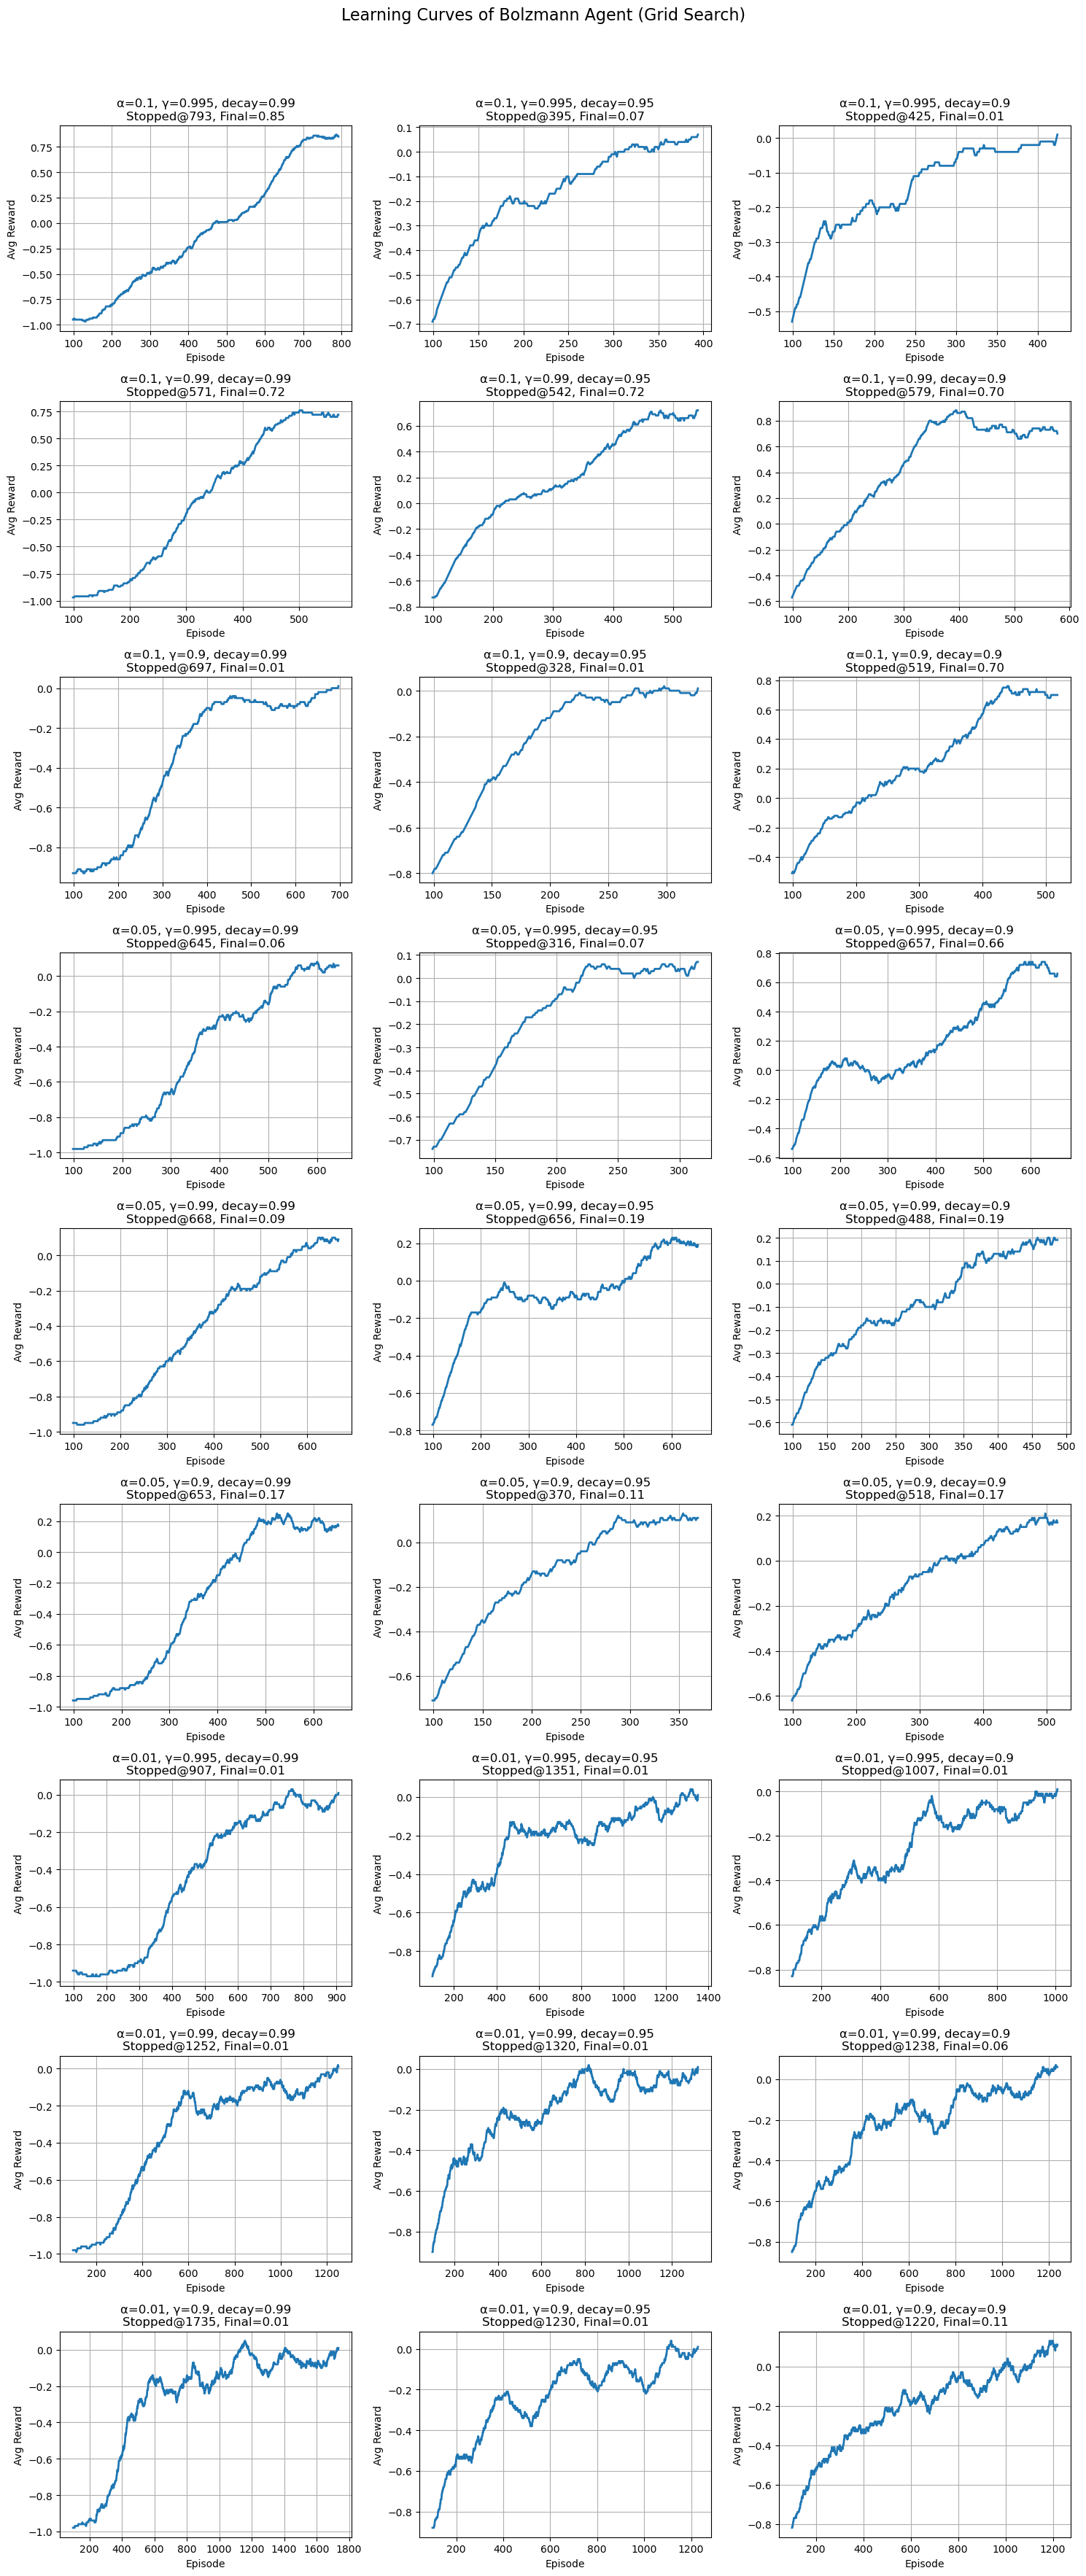

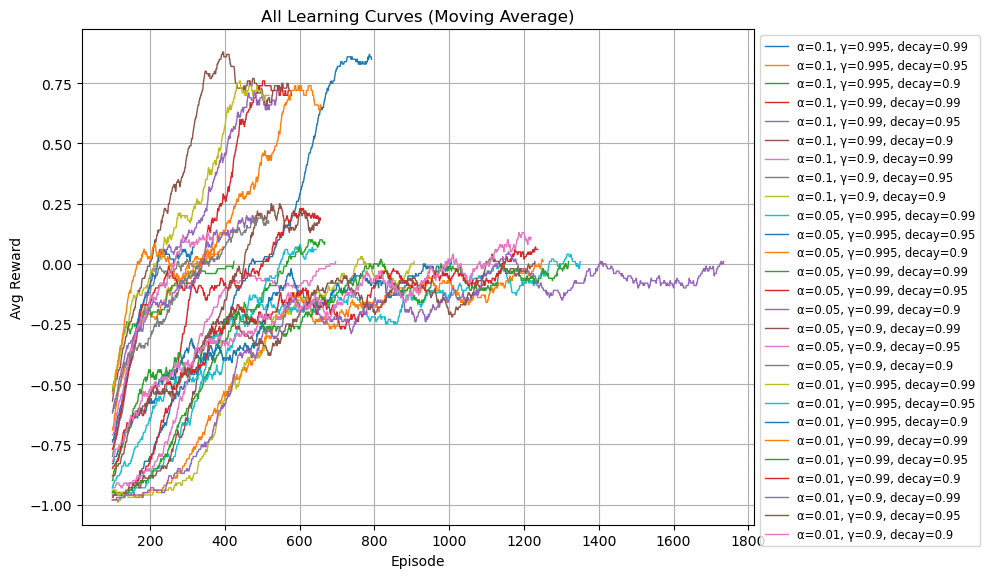

Best Early Convergence Model:
  α=0.05, γ=0.995, decay=0.95
  Stopped at episode 316
  Final avg cumulative reward: 0.07

Best Performance Model:
  α=0.1, γ=0.995, decay=0.99
  Stopped at episode 793
  Final avg cumulative reward: 0.85


In [ ]:
# Grid search parameters
list_of_alpha = [0.1, 0.05, 0.01]
list_of_gamma = [0.995, 0.99, 0.9]
list_of_decay_rate = [0.99, 0.95, 0.9]

param_combinations = list(itertools.product(list_of_alpha, list_of_gamma, list_of_decay_rate))

ncols = 3
nrows = int(np.ceil(len(param_combinations) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

results = []

for idx, (alpha, gamma, decay_rate) in tqdm(enumerate(param_combinations), total=len(param_combinations), desc="Grid Search"):

    # Initialize agent
    agent = BoltzmannAgent(
        temperature=1.0,
        decay_rate=decay_rate,
        min_temperature=0.01,
        gamma=gamma,
        alpha=alpha,
        action_space=ACTION_SPACE,
        n_states=MAP_SIZE * MAP_SIZE,
        n_actions=N_ACTIONS
    )

    stopped_episode = MAX_EPISODES
    episode_rewards = []
    cumulative_rewards = []
    
    inner_pbar = tqdm(total=MAX_EPISODES, leave=False, position=1)
    inner_pbar.set_description(f"[α={alpha}, γ={gamma}, decay={decay_rate}]")

    for episode in range(MAX_EPISODES):
        observation, info = env.reset()
        total_reward = 0

        for step in range(MAX_STEPS):
            action = agent.select_action(observation)
            next_observation, reward, done, info = env.step(action)
            reward = -1 if done and reward == 0 else reward
            agent.update_q_value(observation, action, reward, next_observation)
            observation = next_observation
            total_reward += reward
            if done:
                break

        agent.decay_temperature()
        episode_rewards.append(total_reward)
        cumulative_rewards.append(sum(episode_rewards[-WINDOW_SIZE:]) / WINDOW_SIZE)
        inner_pbar.update(1)

        if episode % 10 == 0 or episode == MAX_EPISODES - 1:
            inner_pbar.set_description(
                f"[α={alpha}, γ={gamma}, decay={decay_rate}] Ep {episode+1}, "
                f"Cumulative: {sum(episode_rewards):.2f}"
            )

        if len(episode_rewards) >= STABLE_WINDOW_SIZE + WINDOW_SIZE and sum(episode_rewards[-WINDOW_SIZE:]) > 0:
            min_cumulative_reward = min(cumulative_rewards[-STABLE_WINDOW_SIZE:])
            max_cumulative_reward = max(cumulative_rewards[-STABLE_WINDOW_SIZE:])
            if abs(max_cumulative_reward - min_cumulative_reward) < STOPPING_THRESHOLD:
                stopped_episode = episode + 1
                break

    inner_pbar.close()
    env.close()

    if len(episode_rewards) >= WINDOW_SIZE:
        final_cumulative_reward = sum(episode_rewards[-WINDOW_SIZE:]) / WINDOW_SIZE
    else:
        final_cumulative_reward = sum(episode_rewards) / len(episode_rewards) if episode_rewards else 0

    episode_avg_rewards = moving_average(episode_rewards, WINDOW_SIZE)

    results.append({
        'alpha': alpha,
        'gamma': gamma,
        'decay_rate': decay_rate,
        'stopped_episode': stopped_episode,
        'final_cumulative_reward': final_cumulative_reward,
        'episode_rewards': episode_rewards.copy()
    })

    ax = axes[idx]
    ax.plot(range(WINDOW_SIZE - 1, len(episode_rewards)), episode_avg_rewards, linewidth=2)
    ax.set_title(
        f"α={alpha}, γ={gamma}, decay={decay_rate}\n"
        f"Stopped@{stopped_episode}, Final={final_cumulative_reward:.2f}"
    )
    ax.set_xlabel("Episode")
    ax.set_ylabel("Avg Reward")
    ax.grid(True)

for ax in axes[len(param_combinations):]:
    ax.axis('off')

global_results["bolzmann"] = copy.deepcopy(results)

plt.suptitle("Learning Curves of Bolzmann Agent (Grid Search)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Plot all learning curves in a single figure
plt.figure(figsize=(10, 6))
for result in results:
    alpha = result['alpha']
    gamma = result['gamma']
    decay_rate = result['decay_rate']
    rewards = result['episode_rewards']
    if len(rewards) >= WINDOW_SIZE:
        avg_rewards = moving_average(rewards, WINDOW_SIZE)
        label = f"α={alpha}, γ={gamma}, decay={decay_rate}"
        plt.plot(range(WINDOW_SIZE - 1, len(rewards)), avg_rewards, label=label, linewidth=1)

plt.title("All Learning Curves (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)
plt.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Best models summary
best_by_stop = min(results, key=lambda x: x['stopped_episode'])
best_by_reward = max(results, key=lambda x: x['final_cumulative_reward'])

print("Best Early Convergence Model:")
print(f"  α={best_by_stop['alpha']}, γ={best_by_stop['gamma']}, decay={best_by_stop['decay_rate']}")
print(f"  Stopped at episode {best_by_stop['stopped_episode']}")
print(f"  Final avg cumulative reward: {best_by_stop['final_cumulative_reward']:.2f}")

print("\nBest Performance Model:")
print(f"  α={best_by_reward['alpha']}, γ={best_by_reward['gamma']}, decay={best_by_reward['decay_rate']}")
print(f"  Stopped at episode {best_by_reward['stopped_episode']}")
print(f"  Final avg cumulative reward: {best_by_reward['final_cumulative_reward']:.2f}")



### Final Analysis  

Now we plot performance graph of windowed cumulative reward and convergence rate for each exprloration experiments.  
Also we have pointed out Pareto frontiers(and at least exceed 0.5 of cumulative reward),  
because there are two optimization criteria(convergence rate, cumulative reward) and it has a weak trade-off relationship 


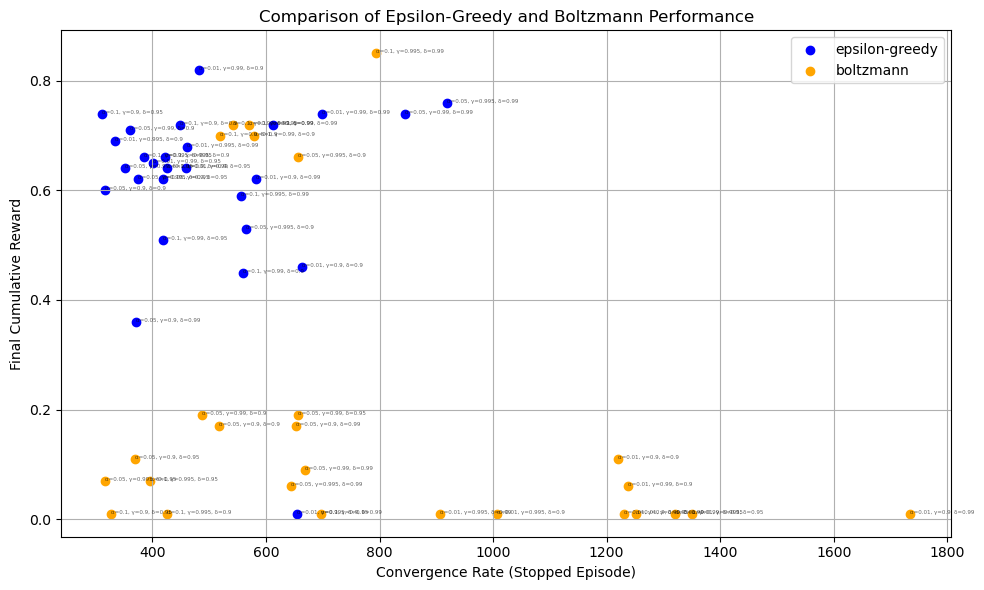

In [ ]:
# Define consistent colors and labels
colors = ['blue', 'orange']
labels = ['epsilon-greedy', 'boltzmann']

# Start plot
plt.figure(figsize=(10, 6))

# Plot each result set with a consistent color and label
for result_set, color, method_label in zip(
        [global_results["epsilon_greedy"], global_results["bolzmann"]],
        colors, labels):
    
    x = [r['stopped_episode'] for r in result_set]
    y = [r['final_cumulative_reward'] for r in result_set]
    plt.scatter(x, y, color=color, label=method_label)

    for r in result_set:
        label_text = f"α={r['alpha']}, γ={r['gamma']}, δ={r['decay_rate']}"
        plt.annotate(label_text, (r['stopped_episode'], r['final_cumulative_reward']),
                     fontsize=4, alpha=0.6)

# Axis labeling
plt.xlabel("Convergence Rate (Stopped Episode)")
plt.ylabel("Final Cumulative Reward")
plt.title("Comparison of Epsilon-Greedy and Boltzmann Performance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


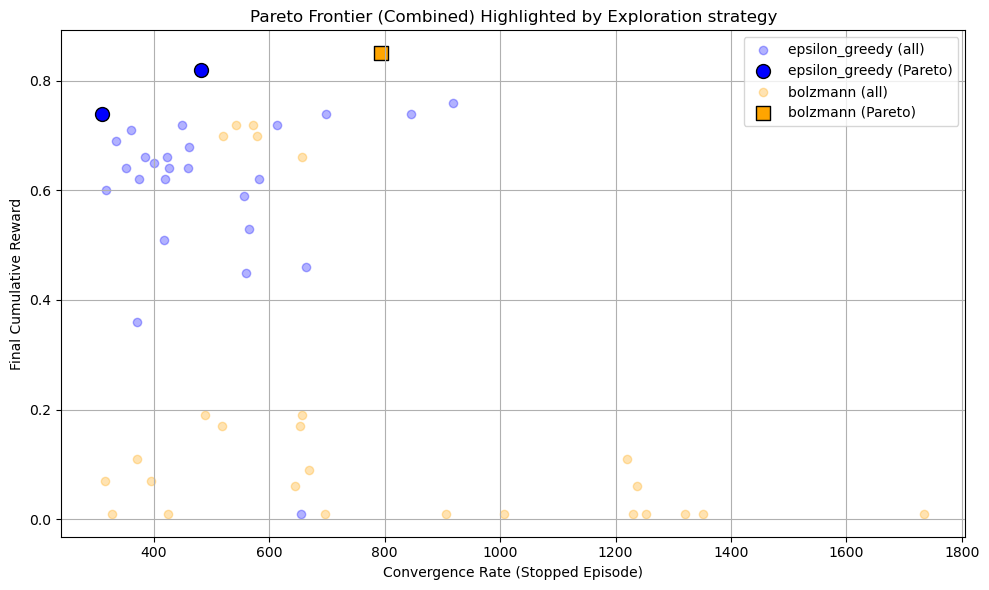

In [ ]:
strategy_names = ["epsilon_greedy", "bolzmann"]

# Combine all data
combined_data = []
for strategy in strategy_names:
    for r in global_results[strategy]:
        r = r.copy()
        r['strategy'] = strategy
        combined_data.append(r)

# Extract all points and compute Pareto mask
all_points = np.array([
    [r['stopped_episode'], r['final_cumulative_reward']]
    for r in combined_data
])
pareto_mask = is_pareto_efficient(all_points) & is_cumulative_reward_exceeding_threshold(all_points)
pareto_data = [combined_data[i] for i in range(len(combined_data)) if pareto_mask[i]]

# Plot
plt.figure(figsize=(10, 6))
colors = {'epsilon_greedy': 'blue', 'bolzmann': 'orange'}
markers = {'epsilon_greedy': 'o', 'bolzmann': 's'}

for strategy in strategy_names:
    results = [r for r in combined_data if r['strategy'] == strategy]
    pareto_results = [r for r in pareto_data if r['strategy'] == strategy]

    x_all = [r['stopped_episode'] for r in results]
    y_all = [r['final_cumulative_reward'] for r in results]
    plt.scatter(x_all, y_all, color=colors[strategy], alpha=0.3, label=f"{strategy} (all)")

    x_pareto = [r['stopped_episode'] for r in pareto_results]
    y_pareto = [r['final_cumulative_reward'] for r in pareto_results]
    plt.scatter(x_pareto, y_pareto, color=colors[strategy], marker=markers[strategy],
                edgecolor='black', s=100, label=f"{strategy} (Pareto)")

plt.xlabel("Convergence Rate (Stopped Episode)")
plt.ylabel("Final Cumulative Reward")
plt.title("Pareto Frontier (Combined) Highlighted by Exploration strategy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()